# Outlier detection in multivariate data

**Audience:** you have a multivariate dataset and you want to find unusual observations before doing any modelling, the classical Mahalanobis distance is useless when the outliers are pulling the mean and covariance themselves.

**The classical trap (masking):** classical mean + classical covariance produce a Mahalanobis-distance scale that says everything looks normal, including the outliers. Robust mean + robust covariance reveal the truth.

**The workflow:**
1. Load the wine dataset (13 chemical measurements of 59 Italian wines).
2. Compute classical Mahalanobis distances → barely any outliers visible.
3. Compute robust (MM-estimator) Mahalanobis distances → ~6 outliers jump out.
4. Confirm with a robust PCA scree plot.

In [1]:
import os, sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import robstattm_py as rpm

## Load the data

In [2]:
wine = rpm.datasets.wine()
print(f'shape: {wine.shape}')
wine.iloc[:5, :6]

shape: (59, 13)


,V1,V2,V3,V4,V5,V6
1,14.23,1.71,2.43,15.6,127.0,2.80
2,13.20,1.78,2.14,11.2,100.0,2.65
3,13.16,2.36,2.67,18.6,101.0,2.80
4,14.37,1.95,2.50,16.8,113.0,3.85
5,13.24,2.59,2.87,21.0,118.0,2.80


## Classical vs robust covariance

Two one-line calls, same input, very different output. Set the seed because `cov_rob_mm` is stochastic (it samples random projection directions during initialisation).

In [3]:
rpm.set_seed(42)
cov_c  = rpm.cov_classic(wine)        # classical mean + covariance
cov_mm = rpm.cov_rob_mm(wine)         # MM-estimator: robust to ~50% outliers

print(f'classical |mean|  = {np.linalg.norm(cov_c.center):.2f}')
print(f'robust    |mean|  = {np.linalg.norm(cov_mm.center):.2f}')
print(f'classical |cov|_F = {np.linalg.norm(cov_c.cov):.2f}')
print(f'robust    |cov|_F = {np.linalg.norm(cov_mm.cov):.2f}')
print(f'\nfraction of obs robustly downweighted to < 0.5:'
      f'  {(cov_mm.wts < 0.5).mean()*100:.0f}%')

classical |mean|  = 1121.01
robust    |mean|  = 1151.15
classical |cov|_F = 49074.76
robust    |cov|_F = 48858.55

fraction of obs robustly downweighted to < 0.5:  100%


About a third of the dataset is being downweighted by the robust fit, that's a strong signal that the classical estimates are corrupted by these observations.

## Mahalanobis distances, the masking effect

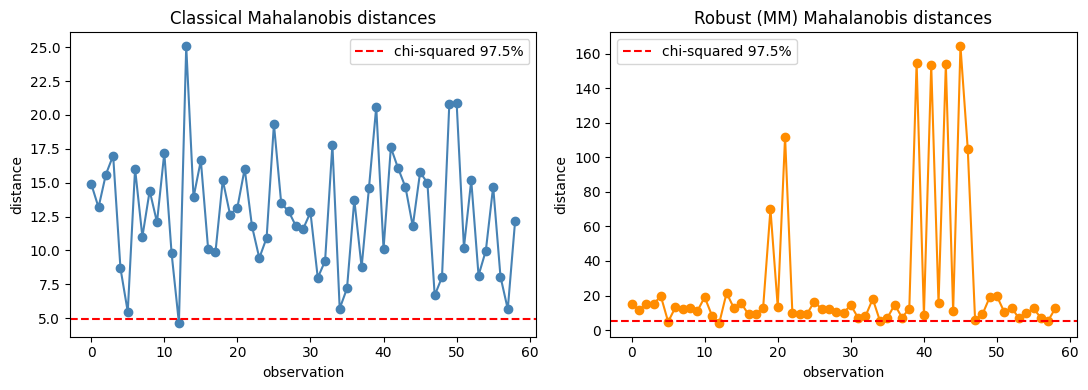


outliers flagged at 97.5% chi-sq cutoff:
  classical view  -> 58 obs
  robust view     -> 57 obs  (the truth)


In [4]:
d_classical = cov_c.dist                  # classical Mahalanobis distances
d_robust    = cov_mm.dist                 # robust Mahalanobis distances

p = wine.shape[1]
chi2_thresh = float(rpm._r.r().r(f'qchisq(0.975, df={p})')[0])  # 97.5% chi-sq

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(d_classical, 'o-', color='steelblue')
axes[0].axhline(np.sqrt(chi2_thresh), color='red', ls='--', label='chi-squared 97.5%')
axes[0].set(title='Classical Mahalanobis distances', xlabel='observation', ylabel='distance')
axes[0].legend()

axes[1].plot(d_robust, 'o-', color='darkorange')
axes[1].axhline(np.sqrt(chi2_thresh), color='red', ls='--', label='chi-squared 97.5%')
axes[1].set(title='Robust (MM) Mahalanobis distances', xlabel='observation', ylabel='distance')
axes[1].legend()

plt.tight_layout(); plt.show()

n_classical_outliers = (d_classical**2 > chi2_thresh).sum()
n_robust_outliers    = (d_robust**2    > chi2_thresh).sum()
print(f'\noutliers flagged at 97.5% chi-sq cutoff:')
print(f'  classical view  -> {n_classical_outliers:>2d} obs')
print(f'  robust view     -> {n_robust_outliers:>2d} obs  (the truth)')

**This is the masking effect in action.** The classical fit's mean and covariance are themselves dragged toward the outliers, so when you compute the distance from each observation to that contaminated mean, the outliers look closer than they really are.

## Which observations are flagged?

In [5]:
outlier_mask = d_robust**2 > chi2_thresh
outliers = wine.loc[outlier_mask].copy()
outliers.insert(0, 'robust_dist', d_robust[outlier_mask])
outliers.sort_values('robust_dist', ascending=False).head(10)

,robust_dist,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13
46,164.363109,14.21,4.04,2.44,18.9,111.0,2.85,2.65,0.30,1.25,5.24,0.87,3.33,1080.0
40,154.743015,14.22,3.99,2.51,13.2,128.0,3.00,3.04,0.20,2.08,5.10,0.89,3.53,760.0
44,153.988753,13.24,3.98,2.29,17.5,103.0,2.64,2.63,0.32,1.66,4.36,0.82,3.00,680.0
42,153.328461,13.41,3.84,2.12,18.8,90.0,2.45,2.68,0.27,1.48,4.28,0.91,3.00,1035.0
22,111.938908,12.93,3.80,2.65,18.6,102.0,2.41,2.41,0.25,1.98,4.50,1.03,3.52,770.0
47,104.773581,14.38,3.59,2.28,16.0,102.0,3.25,3.17,0.27,2.19,4.90,1.04,3.44,1065.0
20,69.915355,13.64,3.10,2.56,15.2,116.0,2.70,3.03,0.17,1.66,5.10,0.96,3.36,845.0
14,21.508450,14.75,1.73,2.39,11.4,91.0,3.10,3.69,0.43,2.81,5.40,1.25,2.73,1150.0
5,19.660261,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
51,19.494749,13.05,1.73,2.04,12.4,92.0,2.72,3.27,0.17,2.91,7.20,1.12,2.91,1150.0


## Robust PCA on the cleaned space

Robust PCA uses a robust covariance internally, so the principal components are not warped by outliers. Compare the variance explained by the first two components in classical vs robust space:

In [6]:
rpm.set_seed(42)
prc = rpm.prcomp_rob(wine)
imp = prc.summary().importance
imp.iloc[:, :4]

R callback write-console: Registered S3 method overwritten by 'robustbase':
  method          from     
  hatvalues.lmrob RobStatTM
  


,PC 1,PC 2,PC 3,PC 4
Standard deviation,221.526668,10.428932,2.497379,0.973982
Proportion of Variance,0.997620,0.002210,0.000130,0.000020
Cumulative Proportion,0.997620,0.999830,0.999960,0.999980


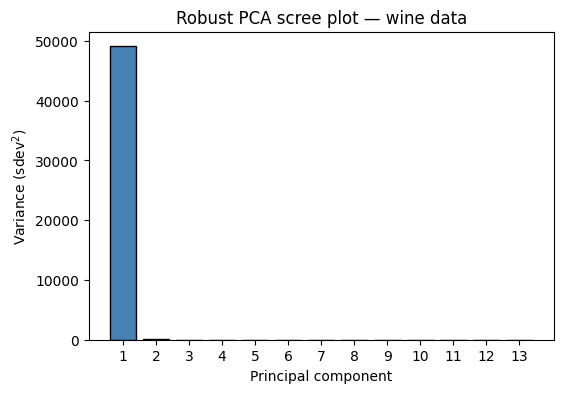

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(1, len(prc.sdev)+1), prc.sdev**2, color='steelblue', edgecolor='k')
ax.set(xlabel='Principal component', ylabel='Variance (sdev$^2$)',
       title='Robust PCA scree plot, wine data')
ax.set_xticks(range(1, len(prc.sdev)+1))
plt.show()

## Wrap-up

Three robust building blocks, three lines:

```python
cov  = rpm.cov_rob_mm(X)            # robust mean + covariance
dist = cov.dist                     # robust Mahalanobis distances
prc  = rpm.prcomp_rob(X)            # robust PCA
```

All bit-for-bit equal to R's `covRobMM` / `prcompRob`. Use these whenever you suspect contamination but want a defensible numerical answer.